<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Description:

*   The main goal of this notebook is to show the same CNN model can be used regardless of the image dimension & class size for different datasets. The ML class is constructed such that varying inputs, outputs dimensions doesn't matter.
*   We are using the same CNN class from CIFAR10 model training




## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
import os

# Check the device enabled

In [2]:
print(torch.__version__)
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')
print(device)

2.8.0+cu126
cuda:0


## Import Datasets - MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]

5 torch.Size([1, 28, 28])


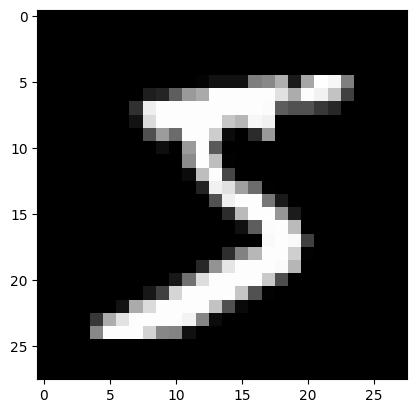

In [3]:
folder = "data"
mnist_train = datasets.MNIST(folder, train = True, download = True, transform = transforms.ToTensor())
mnist_test = datasets.MNIST(folder, train = False, download = True, transform = transforms.ToTensor())
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Normalize the Dataset

torch.Size([1, 28, 28, 60000])
torch.Size([1, 47040000])
tensor([0.1307]) tensor([0.3081])
5 torch.Size([1, 28, 28])


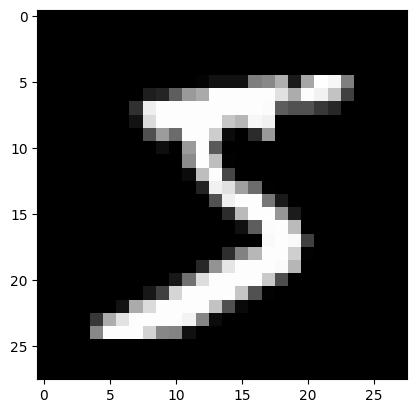

In [4]:
img_stack = torch.stack([img for img, _ in mnist_train], dim=3)
print(img_stack.shape)
img_flat = img_stack.view(1, -1)
print(img_flat.shape)
mu = img_flat.mean(dim = 1)
sigma = img_flat.std(dim=1)
print(mu, sigma)

mnist_train = datasets.MNIST(folder,
                             train = True,
                             download = False,
                             transform = transforms.Compose([
                                 transforms.ToTensor(),
                                 transforms.Normalize(mu, sigma)
                             ]))

mnist_val = datasets.MNIST(folder,
                           train = False,
                           download = False,
                           transform = transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize(mu, sigma)
                           ]))
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Define the CNN Model
This is the same CNN Model defined for CIFAR10 dataset

In [5]:
class NeuralNet(nn.Module):
  def __init__(self, img, nclasses, nchannels = 16, nhidden = 32, kernel_size = 3):
    super().__init__()
    C, H, W = img.shape
    self.conv1 = nn.Conv2d(C, nchannels, kernel_size = kernel_size, padding = kernel_size//2) # Padding used will keep same image dimensions
    self.conv2 = nn.Conv2d(nchannels, nchannels//2, kernel_size = kernel_size, padding = kernel_size//2) # Max pooling only reduces the spatial dims
    self.flat = H//4 * W//4 * nchannels//2
    self.fc1 = nn.Linear(self.flat, nhidden)
    self.fc2 = nn.Linear(nhidden, nclasses)

  def forward(self, x):
    out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
    out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
    out = out.view(-1, self.flat)
    out = torch.tanh(self.fc1(out))
    out = self.fc2(out)           # Depending on classification or regression problem use softmax else just use the raw logits
    return out

## Training loop

In [31]:
def training(nepochs, train_loader, model, loss_fn, optimizer, l_regularizer):
  for epoch in range(nepochs):
    loss_epoch = 0
    time_start = time.time()
    for imgs, labels in train_loader:
      imgs = imgs.to(device=device)
      labels = labels.to(device=device)
      outputs = model(imgs)             # Predicted Output
      loss = loss_fn(outputs, labels)

      l2_norm = sum(p.pow(2).sum() for p in model.parameters()) # Take square of all parameters within one layer, sum it, sum for all the layers
      loss = loss + l2_norm * l_regularizer

      optimizer.zero_grad() # Zero the gradients to avoid adding the current gradients with past gradients from 2 separate batches
      loss.backward()       # Calculate the loss backwards
      optimizer.step()      # Updates the model's parameters: weights & bias

      loss_epoch += loss.item()

    print(f"Epoch: {epoch+1}, Avg Train Loss per batch: {loss_epoch/len(train_loader)}, Time: {time.time()-time_start}")

## Train the Dataset

In [32]:
img = mnist_train[0][0]
img = img.to(device=device)

train_loader = torch.utils.data.DataLoader(mnist_train, batch_size = 64, shuffle = True) # Each batch has 64 images
model = NeuralNet(img, nclasses = 10).to(device = device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 1e-2)

time_start = time.time()
training(
    nepochs = 10,
    train_loader = train_loader,
    model = model,
    loss_fn = loss_fn,
    optimizer = optimizer,
    l_regularizer = 0.001
)
print(f"Train Time: {time.time()-time_start}")

Epoch: 1, Avg Train Loss per batch: 1.343652949150183, Time: 13.44627332687378
Epoch: 2, Avg Train Loss per batch: 0.5511978585392173, Time: 14.075921535491943
Epoch: 3, Avg Train Loss per batch: 0.3911676820216657, Time: 13.474429607391357
Epoch: 4, Avg Train Loss per batch: 0.3190085555254015, Time: 13.682429075241089
Epoch: 5, Avg Train Loss per batch: 0.27737389002908774, Time: 14.132086992263794
Epoch: 6, Avg Train Loss per batch: 0.2507912401419713, Time: 13.356449604034424
Epoch: 7, Avg Train Loss per batch: 0.23297010808547677, Time: 13.320106744766235
Epoch: 8, Avg Train Loss per batch: 0.21993702990032715, Time: 13.333881855010986
Epoch: 9, Avg Train Loss per batch: 0.21021645818787343, Time: 13.336044788360596
Epoch: 10, Avg Train Loss per batch: 0.2027444501580206, Time: 13.223112344741821
Train Time: 135.3819818496704


## Evaluate the model

In [9]:
def eval(data_loader, model):
  with torch.no_grad():
    correct = 0
    total = 0
    for imgs, labels in data_loader:
      imgs = imgs.to(device = device)
      labels = labels.to(device = device)
      outputs = model(imgs)               # Shape: [batch_size, logits for num_classes]
      _, y = torch.max(outputs, dim=1)
      correct += int((labels==y).sum()) # predicted == labels creates a boolean tensor where each element is True if the prediction matches, .sum() calculates the number of True values in that boolean tensor
      total += labels.shape[0]

    accuracy = correct/total
  return accuracy

val_loader = torch.utils.data.DataLoader(mnist_val, batch_size = 64, shuffle  = False)
val_accuracy = eval(val_loader, model)
train_accuracy = eval(train_loader, model)
print(f"Training accuracy: {train_accuracy}, Validation accuracy: {val_accuracy}")


Training accuracy: 0.9663833333333334, Validation accuracy: 0.9673


## Visualize the results

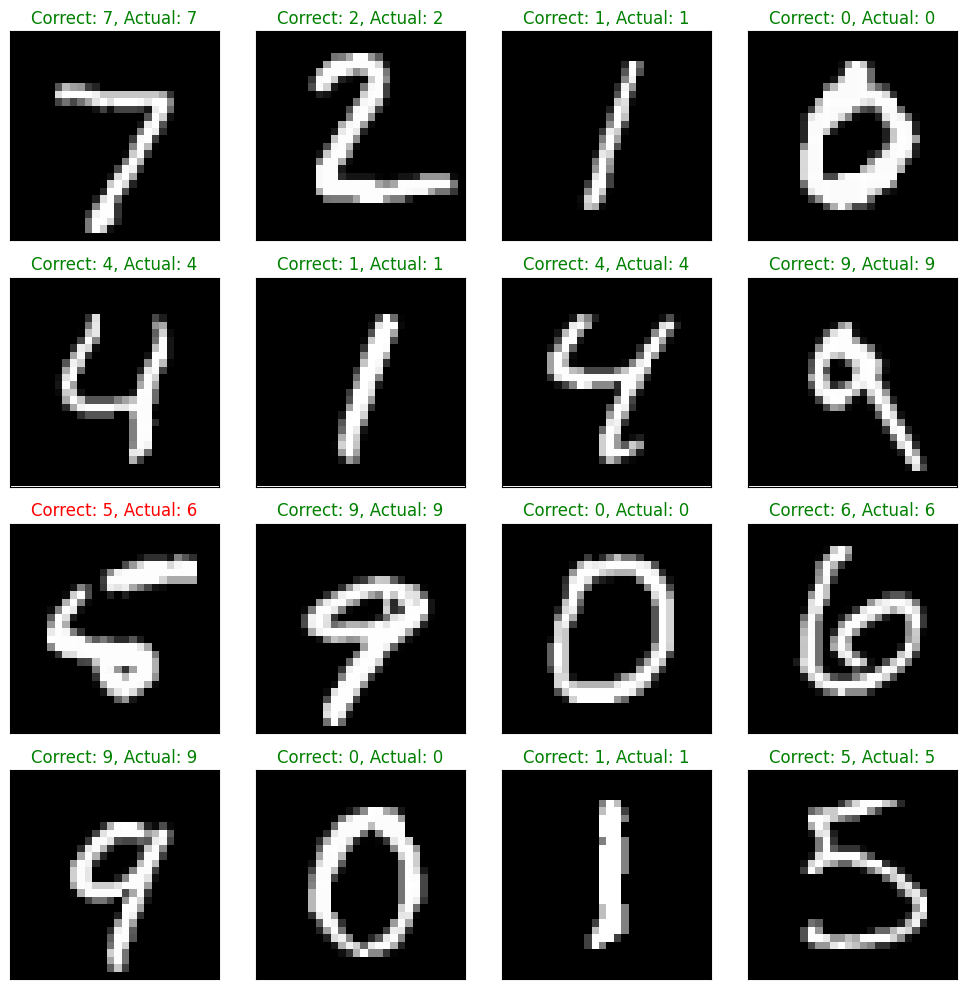

In [30]:
imgs, labels = next(iter(val_loader))

imgs = imgs.to(device=device)
outputs = model(imgs)
_, y = torch.max(outputs, dim=1)

fig = plt.figure(figsize = (10,10))
for i in range(min(16, len(imgs))):
  ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
  img = imgs[i].to(device='cpu')
  ax.imshow(img.permute(1,2,0), cmap='gray')
  color = 'green' if labels[i]==y[i] else 'red'
  ax.set_title(f"Correct: {labels[i].item()}, Actual: {y[i].item()}", color=color)

plt.tight_layout()
plt.show()

